# exp_07 OOD evaluation -- LungHist700 pulmonary dataset

OOD evaluation of LC25000-trained checkpoints on the **LungHist700** lung histopathology dataset (Diosdado et al., 2024, *Scientific Data*). The notebook supports five model architectures via a `VARIANT` switch:

- `baseline` -- `CLIPModel_HF` (ResNet50 image + BERT text + projection heads)
- `plain_classifier` -- ResNet50 -> GAP -> BatchNorm -> Dense(5) softmax
- `plip_bert_composed` -- `CLIPModel_PLIP` (PLIP ViT-B/32 + BERT + projection heads)
- `dinov2_bert_composed` -- `CLIPModel_DINOv2` (DINOv2 ViT-B/14 + BERT + projection heads; exp_10 control)
- `stain_macenko_nct_ref` — `CLIPModel_HF` trained on LC25000 with Macenko(target=NCT-NORM) applied; Macenko applied again at inference here to bring the OOD patches into the same stain space.

## Dataset

- Source: https://figshare.com/articles/dataset/LungHist700_A_Dataset_of_Histological_Images_for_Deep_Learning_in_Pulmonary_Pathology/25459174
- 691 H&E images at 1200x1600 pixels
- 7 classes encoded in the filename: `{class}_{grade}_{magnification}_{idx}.jpg`
    - class: `aca` (adenocarcinoma), `scc` (squamous cell carcinoma), `nor` (normal)
    - grade: `wd` (well-differentiated), `md` (moderately-differentiated), `pd` (poorly-differentiated). Normal has no grade.
    - magnification: `20x` or `40x`
- We use the **20x subset only** to match LC25000's effective magnification.
- LC25000 mapping (3-way restricted argmax):
    - `nor` (any grade)  -> `benign lung tissue`               (LC25000 idx 0)
    - `aca` (any grade)  -> `lung adenocarcinoma`              (LC25000 idx 1)
    - `scc` (any grade)  -> `lung squamous cell carcinoma`     (LC25000 idx 2)

## Setup

Cell 3 tries a Figshare direct download via `wget`. If that fails (Figshare occasionally rotates direct URLs), it falls back to instructions for manual upload to Drive at `/content/drive/MyDrive/TFM/datasets/LungHist700/`.

**Citation:** Diosdado, J. C. et al. *LungHist700: A dataset of histological images for deep learning in pulmonary pathology* (2024). DOI: 10.1038/s41597-024-03944-3.


<a href="https://colab.research.google.com/github/lcandau/histopathology-clip-lab/blob/exp_09_extended_ood_eval/experiments/exp_07_ood_eval/LungHist700_OOD_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 0 -- Bootstrap


In [2]:
# --- Cell 0: bootstrap ---
import os, sys, subprocess
os.environ["KERAS_BACKEND"] = "tensorflow"

REPO_URL = "https://github.com/lcandau/histopathology-clip-lab.git"
REPO_DIR = "/content/histopathology-clip-lab"
BRANCH   = "main"
IN_COLAB = "google.colab" in sys.modules


def _clone_with_fallback(branch):
    try:
        subprocess.run(
            ["git", "clone", "-b", branch, REPO_URL, REPO_DIR],
            check=True, capture_output=True,
        )
        print(f"Cloned branch {branch!r}")
        return branch
    except subprocess.CalledProcessError:
        print(f"Branch {branch!r} not found; cloning main")
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
        return "main"


if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        active = _clone_with_fallback(BRANCH)
    else:
        fetch = subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], capture_output=True)
        if fetch.returncode == 0:
            subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", f"origin/{BRANCH}"], check=True)
            active = BRANCH
        else:
            subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "checkout", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)
            active = "main"
    print(f"Active branch: {active}")
    subprocess.run([
        "pip", "install", "-q",
        "tensorflow==2.18.0", "keras==3.7.0", "keras-hub==0.18.1",
        "transformers==4.46.0", "umap-learn", "kagglehub",
        "scikit-learn", "matplotlib", "pandas", "Pillow",
    ], check=True)
    subprocess.run(["pip", "uninstall", "-y", "-q", "jax", "jaxlib"], check=False)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
else:
    LOCAL_REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    if LOCAL_REPO_DIR not in sys.path:
        sys.path.insert(0, LOCAL_REPO_DIR)

print("In Colab:", IN_COLAB)
print("sys.path[0]:", sys.path[0])
print("KERAS_BACKEND:", os.environ.get("KERAS_BACKEND"))


Active branch: main
Mounted at /content/drive
In Colab: True
sys.path[0]: /content/histopathology-clip-lab
KERAS_BACKEND: tensorflow


## 1 -- Imports


In [3]:
# --- Cell 1: imports ---
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import json
import math
import shutil
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
import keras
import keras_hub

from transformers import AutoTokenizer, TFAutoModel, TFCLIPVisionModel
# NOTE: DINOv2 has no TF port in transformers==4.46.0 -- the dinov2_bert_composed
# variant consumes features precomputed by DINOv2_feature_precompute.ipynb.

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score,
)

from src.utils.paths import is_colab, repo_root, drive_root, run_dir, results_dir
from src.utils.repro import set_global_seed, enable_op_determinism
from src.data.lc25000 import (
    CLASS_INFO, NUM_CLASSES, CLASS_NAMES, INDEX_TO_NAME, ID_TO_INDEX,
    discover_records, stratified_split, save_split, load_split,
)
from src.prompts.templates import baseline_prompt


## 2 -- Configuration (VARIANT switch lives here)


In [4]:
# --- Cell 2: config ---
EXPERIMENT = "exp_07_ood_eval"
DATASET_TAG = "lunghist700_20x"   # short tag used in output filenames

# --- VARIANT SWITCH (toggle and re-run from Cell 5 onwards) ---
# One of: "baseline", "plain_classifier", "plip_bert_composed", "dinov2_bert_composed", "stain_macenko_nct_ref"
VARIANT = "stain_macenko_nct_ref"

SEED = 42
set_global_seed(SEED)
enable_op_determinism()

IMG_SIZE   = 224
MAX_LEN    = 24
EMBED_DIM  = 256
INIT_TEMP  = 0.07
BATCH_SIZE = 64

# --- LC25000 target classes for restricted argmax ---
# Each VARIANT lands in one of three families; the restricted-argmax indices
# are the same regardless of variant (CLIP-style cosine vs softmax logits both
# index the same 5-way LC25000 class space).
TARGET_LC_NAMES = [
    'benign lung tissue',
    'lung adenocarcinoma',
    'lung squamous cell carcinoma',
]
TARGET_LC_IDX = sorted({
    ID_TO_INDEX[next(c.id for c in CLASS_INFO if c.name == n)]
    for n in TARGET_LC_NAMES
})

# --- PLIP image normalisation constants (only used when VARIANT == plip_bert_composed) ---
PLIP_MODEL_ID   = "vinid/plip"
TEXT_ENCODER_ID = "bert-base-uncased"
PLIP_MEAN = np.array([0.48145466, 0.4578275, 0.40821073], dtype=np.float32)
PLIP_STD  = np.array([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)

# --- DINOv2 precomputed-feature cache (only used when VARIANT == dinov2_bert_composed) ---
# Features are precomputed by experiments/exp_10_dinov2_backbone/DINOv2_feature_precompute.ipynb.
DINOV2_MODEL_ID = "facebook/dinov2-base"
DINOV2_VISION_HIDDEN = 768
DINOV2_CACHE_ROOT = Path("/content/drive/MyDrive/clip_histopathology/cache/dinov2")
DINOV2_OOD_CACHE_PATH     = DINOV2_CACHE_ROOT / f"{DATASET_TAG}.h5"
DINOV2_LC25000_CACHE_PATH = DINOV2_CACHE_ROOT / "lc25000.h5"

# --- Per-variant checkpoint paths (mirror the exp_07 OOD eval notebooks) ---
_CHECKPOINT_MAP = {
    "baseline":             run_dir("exp_01_baseline",      "baseline")             / "weights.weights.h5",
    "plain_classifier":     run_dir("exp_03_plain_classifier", "plain_classifier")  / "weights.weights.h5",
    "plip_bert_composed":   run_dir("exp_08_plip_backbone", "plip_bert_composed")   / "weights.weights.h5",
    "dinov2_bert_composed": run_dir("exp_10_dinov2_backbone", "dinov2_bert_composed") / "weights.weights.h5",
    "stain_macenko_nct_ref": run_dir("exp_04_stain_normalization", "stain_macenko_nct_ref") / "weights.weights.h5",
}
assert VARIANT in _CHECKPOINT_MAP, f"Unknown VARIANT {VARIANT!r}; pick one of {list(_CHECKPOINT_MAP)}"
CHECKPOINT_PATH = _CHECKPOINT_MAP[VARIANT]

METRICS_DIR = results_dir("metrics") / EXPERIMENT
CM_DIR      = results_dir("confusion_matrices") / EXPERIMENT
PLOTS_DIR   = results_dir("plots") / EXPERIMENT
for d in (METRICS_DIR, CM_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

OUT_TAG = f"{VARIANT}_{DATASET_TAG}"

print(f"Variant:        {VARIANT}")
print(f"Dataset tag:    {DATASET_TAG}")
print(f"Checkpoint:     {CHECKPOINT_PATH}")
print(f"Target classes: {TARGET_LC_NAMES}  -> LC25000 indices {TARGET_LC_IDX}")
print(f"Metrics out:    {METRICS_DIR}")
if VARIANT == "dinov2_bert_composed":
    print(f"DINOv2 cache:   {DINOV2_OOD_CACHE_PATH}")
    print(f"  + LC25000:    {DINOV2_LC25000_CACHE_PATH}")


Variant:        stain_macenko_nct_ref
Dataset tag:    lunghist700_20x
Checkpoint:     /content/drive/MyDrive/clip_histopathology/exp_04_stain_normalization/stain_macenko_nct_ref/weights.weights.h5
Target classes: ['benign lung tissue', 'lung adenocarcinoma', 'lung squamous cell carcinoma']  -> LC25000 indices [0, 1, 2]
Metrics out:    /content/histopathology-clip-lab/results/metrics/exp_07_ood_eval


## 3 -- Download / locate LungHist700


In [5]:
# --- Cell 3: locate LungHist700 on Drive (rar-on-Drive pattern) ---
# Workflow:
#   1. User downloads LungHist700.rar from Figshare (the dataset ships as a .rar,
#      NOT a .zip; auto-downloading via the Figshare API hits a format mismatch
#      and adds no value over a manual upload).
#        https://figshare.com/articles/dataset/LungHist700_A_Dataset_of_Histological_Images_for_Deep_Learning_in_Pulmonary_Pathology/25459174
#   2. User uploads LungHist700.rar (~640 MB) to /content/drive/MyDrive/TFM/datasets/.
#   3. This cell installs `unrar` if missing, extracts the rar into LUNGHIST_DRIVE_DIR
#      on first run, and uses the extracted tree on subsequent runs.
#
# Layout inside the rar (verified against the official 2024 release):
#   data/data.csv                                 (per-image labels)
#   data/images/{aca_bd,aca_md,aca_pd}/*.jpg      (adenocarcinoma x grades)
#   data/images/{scc_bd,scc_md,scc_pd}/*.jpg      (squamous x grades)
#   data/images/nor/*.jpg                         (normal, no grade subdivision)
#
# Filenames encode class+grade+magnification: e.g. `aca_bd_20x_0.jpg`,
# `scc_pd_40x_15.jpg`, `nor_40x_99.jpg`. The filename parser in Cell 4 collapses
# grades, keeps only 20x, and maps {aca,scc,nor} -> the 3 LC25000 lung classes.

LUNGHIST_DRIVE_DIR = Path("/content/drive/MyDrive/TFM/datasets/LungHist700") if IN_COLAB \
    else Path(os.environ.get("LUNGHIST_LOCAL_DIR", "/tmp/LungHist700"))
LUNGHIST_DATASETS_DIR = LUNGHIST_DRIVE_DIR.parent  # /content/drive/MyDrive/TFM/datasets/


def _has_images(d: Path) -> bool:
    if not d.exists():
        return False
    return any(True for _ in d.rglob("*.jpg")) or any(True for _ in d.rglob("*.png"))


def _find_lunghist_archive(search_dir: Path):
    """Find LungHist700.rar (or *.zip / *.tar.gz fallback) in search_dir."""
    if not search_dir.exists():
        return None
    for pattern in ("LungHist*.rar", "lunghist*.rar", "LungHist*.zip", "lunghist*.zip"):
        hits = sorted(search_dir.glob(pattern))
        if hits:
            return hits[0]
    return None


def _ensure_unrar():
    """Install unrar via apt if not present (Colab)."""
    import shutil as _sh
    if _sh.which("unrar") is not None:
        return
    print("Installing unrar (apt-get) ...")
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "unrar"],
        check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    )


def _extract_archive(archive_path: Path, dest_dir: Path):
    dest_dir.mkdir(parents=True, exist_ok=True)
    size_mb = archive_path.stat().st_size / 1e6
    if archive_path.suffix.lower() == ".rar":
        _ensure_unrar()
        print(f"Extracting {archive_path.name} ({size_mb:.1f} MB) via unrar -> {dest_dir} ...")
        # -o+ overwrites existing; idempotent
        subprocess.run(
            ["unrar", "x", "-o+", "-inul", str(archive_path), str(dest_dir) + "/"],
            check=True,
        )
    elif archive_path.suffix.lower() == ".zip":
        print(f"Extracting {archive_path.name} ({size_mb:.1f} MB) via zipfile -> {dest_dir} ...")
        with zipfile.ZipFile(archive_path) as zf:
            zf.extractall(dest_dir)
    else:
        raise ValueError(f"Unsupported archive format: {archive_path.suffix}")
    print("  done.")


# --- Resolution order: extracted on Drive -> archive on Drive -> manual upload ---
if not _has_images(LUNGHIST_DRIVE_DIR):
    archive = _find_lunghist_archive(LUNGHIST_DATASETS_DIR)
    if archive is None:
        raise FileNotFoundError(
            f"\nLungHist700 not found.\n"
            f"Looked for extracted images at: {LUNGHIST_DRIVE_DIR}\n"
            f"Looked for an archive in:       {LUNGHIST_DATASETS_DIR}\n"
            "\nSteps to fix:\n"
            "  1. Open the Figshare landing page:\n"
            "       https://figshare.com/articles/dataset/LungHist700_A_Dataset_of_Histological_Images_for_Deep_Learning_in_Pulmonary_Pathology/25459174\n"
            "  2. Download the dataset (it ships as LungHist700.rar, ~640 MB).\n"
            f"  3. Upload the .rar to {LUNGHIST_DATASETS_DIR}.\n"
            "  4. Re-run this cell. The archive will be extracted to Drive once and cached.\n"
        )
    _extract_archive(archive, LUNGHIST_DRIVE_DIR)
    assert _has_images(LUNGHIST_DRIVE_DIR), \
        f"Extraction completed but no .jpg/.png found under {LUNGHIST_DRIVE_DIR}"

LUNGHIST_ROOT = LUNGHIST_DRIVE_DIR

# Summary
n_all = sum(1 for _ in LUNGHIST_ROOT.rglob("*.jpg")) + sum(1 for _ in LUNGHIST_ROOT.rglob("*.png"))
csv_files = list(LUNGHIST_ROOT.rglob("data.csv"))
print(f"LungHist700 root: {LUNGHIST_ROOT}")
print(f"Total images:     {n_all}")
print(f"Label CSV present: {bool(csv_files)} ({csv_files[0] if csv_files else 'not found'})")

LungHist700 root: /content/drive/MyDrive/TFM/datasets/LungHist700
Total images:     691
Label CSV present: True (/content/drive/MyDrive/TFM/datasets/LungHist700/data/data.csv)


## 4 -- Parse filename labels, filter to 20x, build LC25000 mapping


In [6]:
# --- Cell 4: parse LungHist700 filenames + LC25000 mapping ---
# LungHist700 filenames follow the convention (from the Scientific Data paper):
#   {class}_{grade}_{magnification}_{idx}.jpg     e.g. aca_wd_20x_001.jpg
# where:
#   class:         "aca" | "scc" | "nor"
#   grade:         "wd" | "md" | "pd"     (omitted / absent for normal)
#   magnification: "20x" | "40x"
#
# Some releases use slightly different separators (e.g. "aca_bd_20x" with `bd` for
# "benign differentiation"), so we tokenise robustly.
import re

LUNG_CLS_PATTERNS = {
    "aca": "lung adenocarcinoma",
    "scc": "lung squamous cell carcinoma",
    "nor": "benign lung tissue",
}
LUNG_MAG_TARGET = "20x"


def _parse_lunghist_filename(name: str):
    """Return (class_token, magnification_token) or (None, None) if unparseable."""
    stem = Path(name).stem.lower()
    tokens = re.split(r"[_\-\s]+", stem)
    cls = None
    mag = None
    for t in tokens:
        if t in LUNG_CLS_PATTERNS and cls is None:
            cls = t
        if t in {"20x", "40x"} and mag is None:
            mag = t
    return cls, mag


all_lung_files = sorted([p for p in LUNGHIST_ROOT.rglob("*.jpg")]
                        + [p for p in LUNGHIST_ROOT.rglob("*.png")])

ood_paths_list = []
ood_lh_cls_list = []
unparsed = []
counts_by_mag = {"20x": 0, "40x": 0, "unknown": 0}
counts_by_cls_at_20x = {"aca": 0, "scc": 0, "nor": 0}

for f in all_lung_files:
    cls, mag = _parse_lunghist_filename(f.name)
    if mag in counts_by_mag:
        counts_by_mag[mag] += 1
    else:
        counts_by_mag["unknown"] += 1
    if cls is None or mag != LUNG_MAG_TARGET:
        if cls is None:
            unparsed.append(f.name)
        continue
    ood_paths_list.append(str(f))
    ood_lh_cls_list.append(cls)
    counts_by_cls_at_20x[cls] += 1

ood_paths       = np.asarray(ood_paths_list)
ood_lh_cls      = np.asarray(ood_lh_cls_list)
ood_lc_indices  = np.array([
    ID_TO_INDEX[next(c.id for c in CLASS_INFO if c.name == LUNG_CLS_PATTERNS[t])]
    for t in ood_lh_cls
], dtype=np.int32)

print(f"Total LungHist700 files inspected: {len(all_lung_files)}")
print(f"  by magnification: {counts_by_mag}")
print(f"\nKept {len(ood_paths)} images at {LUNG_MAG_TARGET}:")
for k, v in counts_by_cls_at_20x.items():
    print(f"  {k} ({LUNG_CLS_PATTERNS[k]}): {v}")
if unparsed:
    print(f"\nWARNING: {len(unparsed)} filenames did not match the expected pattern (showing first 5):")
    for n in unparsed[:5]:
        print(f"  {n}")
    print("  -> these were skipped. Check the filename convention above.")
print(f"\nLC25000 target class indices: {TARGET_LC_IDX}")


Total LungHist700 files inspected: 691
  by magnification: {'20x': 359, '40x': 332, 'unknown': 0}

Kept 359 images at 20x:
  aca (lung adenocarcinoma): 146
  scc (lung squamous cell carcinoma): 128
  nor (benign lung tissue): 85

LC25000 target class indices: [0, 1, 2]


In [7]:
# --- Cell: Macenko precompute (only when VARIANT == "stain_macenko_nct_ref") ---
# Bulk-applies Macenko(target=NCT-NORM) to every patch the model will see, and
# caches the normalised JPEGs. Two cache layers (mirroring the training notebook):
#   1. Local Colab filesystem (fast, ephemeral)
#   2. Drive tarball at clip_histopathology/normalized_cache/ (durable across sessions;
#      one tarball moves ~50x faster than thousands of small files via Drive sync).
#
# The Macenko fitter is built once (on the NCT-NORM reference) and reused for every
# patch list passed through `_macenko_cache_paths`. After this cell, `ood_paths` is
# rewritten to point at the cached normalised JPEGs. The LC25000-test patches are
# rewritten further down (Cell 26) so the UMAP scatter + thumbnails also reflect
# what the model actually consumes.

if VARIANT == "stain_macenko_nct_ref":
    import shutil, tarfile, time
    from tqdm.auto import tqdm
    from src.data.stain import get_fitter

    DRIVE_CACHE_ROOT = Path("/content/drive/MyDrive/clip_histopathology/normalized_cache")
    REF_PATH = Path(repo_root()) / "src" / "data" / "macenko_reference_nct_norm.png"
    assert REF_PATH.is_file(), f"Missing Macenko reference at {REF_PATH}"

    print(f"Fitting Macenko on the NCT-NORM reference: {REF_PATH}")
    _ref_img = np.asarray(Image.open(REF_PATH).convert("RGB"))
    _macenko_fitter = get_fitter("macenko").fit(_ref_img)


    def _macenko_cache_paths(input_paths, cache_key):
        """Macenko-normalise every path in `input_paths` (cached) and return rewritten paths.

        `cache_key` disambiguates the cache namespace, e.g.:
          - f"{DATASET_TAG}_ood"  (one per OOD dataset)
          - "lc25000_test"        (shared across notebooks)
        """
        local_root = Path("/content/normalized_ood/macenko_nct_ref") / f"{cache_key}_{IMG_SIZE}"
        local_root.mkdir(parents=True, exist_ok=True)
        drive_tar = DRIVE_CACHE_ROOT / f"ood_{cache_key}_macenko_nct_ref_{IMG_SIZE}.tar"

        # Detect basename collisions in the input list.
        stems = [Path(p).stem for p in input_paths]
        if len(set(stems)) != len(stems):
            raise RuntimeError(
                f"input_paths (cache_key={cache_key!r}) has duplicate basenames -- "
                "the Macenko cache would collide."
            )

        def _cache_path_for(src_path):
            return local_root / (Path(src_path).stem + ".jpg")

        # Layer 1: local cache check.
        expected_count = len(input_paths)
        existing_local = list(local_root.glob("*.jpg"))
        if len(existing_local) >= expected_count:
            print(f"  [{cache_key}] local cache already populated ({len(existing_local)} files).")
        else:
            # Layer 2: try hydrating from Drive tarball.
            hydrated = False
            if IN_COLAB and drive_tar.is_file():
                print(f"  [{cache_key}] hydrating from Drive: {drive_tar}")
                t0 = time.time()
                with tarfile.open(drive_tar, "r") as tar:
                    tar.extractall(local_root.parent)
                hydrated = True
                print(f"    extracted in {time.time()-t0:.1f}s")
            elif IN_COLAB:
                print(f"  [{cache_key}] no Drive tarball; computing from scratch...")
            else:
                print(f"  [{cache_key}] local-only environment; computing from scratch...")

            # Layer 3: compute any patches still missing after the hydration attempt.
            missing = [p for p in input_paths if not _cache_path_for(p).is_file()]
            if missing:
                if hydrated:
                    print(f"    hydrated cache was incomplete; computing {len(missing)} extra patches.")
                for src_path in tqdm(missing, desc=f"Macenko {cache_key}"):
                    img = np.asarray(
                        Image.open(src_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
                    )
                    norm = _macenko_fitter.transform(img)
                    Image.fromarray(norm).save(_cache_path_for(src_path), format="JPEG", quality=95)

                # Save the newly-built cache to Drive.
                if IN_COLAB:
                    DRIVE_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
                    print(f"  [{cache_key}] saving cache to Drive: {drive_tar}")
                    t0 = time.time()
                    with tarfile.open(drive_tar, "w") as tar:
                        tar.add(local_root, arcname=local_root.name)
                    size_mb = drive_tar.stat().st_size / 1e6
                    print(f"    saved {size_mb:.1f} MB in {time.time()-t0:.1f}s")

        rewritten = np.asarray([str(_cache_path_for(p)) for p in input_paths])
        missing_after = [p for p in rewritten if not Path(p).is_file()]
        assert not missing_after, f"Cache materialisation failed; first missing: {missing_after[0]!r}"
        return rewritten


    ood_paths = _macenko_cache_paths(ood_paths, f"{DATASET_TAG}_ood")
    print(f"ood_paths now point at the Macenko cache.")
else:
    print(f"VARIANT={VARIANT} -> no stain precompute (raw OOD paths used).")


Fitting Macenko on the NCT-NORM reference: /content/histopathology-clip-lab/src/data/macenko_reference_nct_norm.png
  [lunghist700_20x_ood] hydrating from Drive: /content/drive/MyDrive/clip_histopathology/normalized_cache/ood_lunghist700_20x_ood_macenko_nct_ref_224.tar


/tmp/ipykernel_5225/3075829212.py:62: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(local_root.parent)


    extracted in 1.8s
ood_paths now point at the Macenko cache.


## 5 -- Image loader (variant-gated preprocessing)


In [8]:
# --- Cell: image loader (variant-gated) ---
# Two preprocessing paths:
#   - baseline / plain_classifier  -> /255.0 RGB in [0, 1]   (matches keras_hub resnet_50_imagenet)
#   - plip_bert_composed           -> /255.0 then CLIP mean/std (matches HF TFCLIPVisionModel)
#
# For VARIANT == "stain_macenko_nct_ref" the Macenko(target=NCT-NORM) transform
# is applied during the precompute cell (Macenko cache), so `ood_paths` already
# points at the normalised JPEGs by the time this loader runs. The loader is
# therefore stain-variant-agnostic.


def load_pil_array(path):
    """Read a JPEG/PNG via PIL, resize to IMG_SIZE, return a float32 [0, 1] RGB array."""
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0


def preprocess_for_variant(arr01):
    """Apply variant-specific channel normalisation on top of a [0,1] RGB array."""
    if VARIANT == "plip_bert_composed":
        return (arr01 - PLIP_MEAN) / PLIP_STD
    # baseline + plain_classifier + stain_macenko_nct_ref expect raw /255.0;
    # dinov2 never calls this fn.
    return arr01


if VARIANT == "plip_bert_composed":
    _pre_label = "CLIP mean/std normalisation"
elif VARIANT == "dinov2_bert_composed":
    _pre_label = "(no per-image preprocessing -- features precomputed in PyTorch)"
elif VARIANT == "stain_macenko_nct_ref":
    _pre_label = "raw /255.0 (Macenko applied upstream in the precompute cell)"
else:
    _pre_label = "raw /255.0"
print(f"Preprocessing path for VARIANT={VARIANT}: {_pre_label}")


Preprocessing path for VARIANT=stain_macenko_nct_ref: raw /255.0 (Macenko applied upstream in the precompute cell)


## 6 -- Model construction (variant-gated)


In [9]:
# --- Cell: model construction (variant-gated) ---
# Each variant builds a model and assigns:
#   - encode_paths(paths) : (N, embed_dim) L2-normalised image embeddings
#   - score(image_emb)    : (N, 5) similarity/logit vector against the 5 LC25000 classes
#                            (cosine sim for CLIP variants; raw logits for plain_classifier)
# The downstream restricted-argmax cell then indexes score with TARGET_LC_IDX.

# We also expose a single `image_features(paths)` -> (N, F) "feature space" used
# by the shared UMAP. For CLIP variants, F = EMBED_DIM (projected unit vectors).
# For plain_classifier, F = 2048 (post-BN pooled ResNet features).


def _l2(x, axis=-1):
    return tf.math.l2_normalize(x, axis=axis)


if VARIANT in ("baseline", "plain_classifier", "stain_macenko_nct_ref"):
    image_backbone = keras_hub.models.Backbone.from_preset("resnet_50_imagenet")
    image_backbone.trainable = False

if VARIANT in ("baseline", "stain_macenko_nct_ref"):
    text_backbone = keras_hub.models.Backbone.from_preset("bert_base_en_uncased")
    text_backbone.trainable = False
    text_pre = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
        "bert_base_en_uncased", sequence_length=MAX_LEN,
    )

    class CLIPModel_HF(keras.Model):
        def __init__(self, img_backbone, text_backbone, embed_dim=EMBED_DIM, init_temp=INIT_TEMP, **kwargs):
            super().__init__(**kwargs)
            self.img_backbone  = img_backbone
            self.text_backbone = text_backbone
            self.img_projection = keras.Sequential([
                keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
                keras.layers.LayerNormalization(dtype="float32"),
            ], name="img_projection")
            self.text_projection = keras.Sequential([
                keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
                keras.layers.LayerNormalization(dtype="float32"),
            ], name="text_projection")
            self.logit_scale = self.add_weight(
                name="logit_scale", shape=(),
                initializer=keras.initializers.Constant(math.log(1.0 / init_temp)),
                trainable=True, dtype="float32",
            )
            self.loss_tracker = keras.metrics.Mean(name="loss")

        @property
        def metrics(self):
            return [self.loss_tracker]

        def encode_image(self, images, training=False):
            features = self.img_backbone(images, training=False)
            if features.shape.rank == 4:
                features = tf.reduce_mean(features, axis=[1, 2])
            return _l2(self.img_projection(features))

        def encode_text(self, token_dict, training=False):
            out = self.text_backbone(token_dict, training=False)
            if isinstance(out, dict):
                features = out.get("pooled_output", out.get("sequence_output"))
                if features is not None and features.shape.rank == 3:
                    features = features[:, 0, :]
            else:
                features = out[:, 0, :] if out.shape.rank == 3 else out
            return _l2(self.text_projection(features))

        def call(self, inputs, training=False):
            images, token_dict = inputs
            return self.encode_image(images, training=training), self.encode_text(token_dict, training=training)

    model = CLIPModel_HF(image_backbone, text_backbone)
    class_prompts = [baseline_prompt(name) for name in CLASS_NAMES]
    class_token_dict = text_pre(tf.constant(class_prompts))
    _ = model((tf.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
               {k: tf.constant(v[:1]) for k, v in class_token_dict.items()}),
              training=False)

elif VARIANT == "plain_classifier":
    inputs   = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
    features = image_backbone(inputs, training=False)
    features = keras.layers.GlobalAveragePooling2D(name="gap")(features)
    features = keras.layers.BatchNormalization(name="feature_norm", dtype="float32")(features)
    logits   = keras.layers.Dense(NUM_CLASSES, name="classifier",
                                  kernel_initializer="glorot_uniform", dtype="float32")(features)
    model = keras.Model(inputs=inputs, outputs=[logits, features], name="plain_classifier_with_features")
    _ = model(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32), training=False)

elif VARIANT == "plip_bert_composed":
    def _load_plip_vision():
        try:
            m = TFCLIPVisionModel.from_pretrained(PLIP_MODEL_ID, from_pt=False)
        except (OSError, EnvironmentError, TypeError, ValueError):
            m = TFCLIPVisionModel.from_pretrained(PLIP_MODEL_ID, from_pt=True)
        m.trainable = False
        return m

    def _load_bert_text(encoder_id=TEXT_ENCODER_ID):
        tokenizer = AutoTokenizer.from_pretrained(encoder_id)
        try:
            m = TFAutoModel.from_pretrained(encoder_id, from_pt=False)
        except (OSError, EnvironmentError, TypeError, ValueError):
            m = TFAutoModel.from_pretrained(encoder_id, from_pt=True)
        m.trainable = False
        return m, tokenizer, m.config.hidden_size

    print("Loading PLIP vision encoder...")
    plip_vision = _load_plip_vision()
    print("Loading BERT text encoder...")
    text_backbone, tokenizer, _text_hidden = _load_bert_text()

    def tokenize_prompts(tokenizer, prompts, max_len=MAX_LEN):
        out = tokenizer(prompts, padding="max_length", truncation=True,
                        max_length=max_len, return_tensors="tf")
        return {k: tf.cast(v, tf.int32) for k, v in out.items()}

    class CLIPModel_PLIP(keras.Model):
        def __init__(self, vision_model, text_backbone, embed_dim=EMBED_DIM,
                     init_temp=INIT_TEMP, **kwargs):
            super().__init__(**kwargs)
            self.vision_model  = vision_model
            self.text_backbone = text_backbone
            self.img_projection = keras.Sequential([
                keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
                keras.layers.LayerNormalization(dtype="float32"),
            ], name="img_projection")
            self.text_projection = keras.Sequential([
                keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
                keras.layers.LayerNormalization(dtype="float32"),
            ], name="text_projection")
            self.logit_scale = self.add_weight(
                name="logit_scale", shape=(),
                initializer=keras.initializers.Constant(math.log(1.0 / init_temp)),
                trainable=True, dtype="float32",
            )
            self.loss_tracker = keras.metrics.Mean(name="loss")

        @property
        def metrics(self):
            return [self.loss_tracker]

        def encode_image(self, pixel_values, training=False):
            # CRITICAL: HF's TFCLIPVisionEmbeddings expects NCHW (PyTorch convention).
            # tf.data feeds NHWC, so we transpose here.
            pixel_values = tf.transpose(pixel_values, perm=[0, 3, 1, 2])
            out = self.vision_model(pixel_values=pixel_values, training=False)
            features = out.pooler_output
            return _l2(self.img_projection(features))

        def encode_text(self, token_dict, training=False):
            kwargs = {"input_ids": token_dict["input_ids"],
                      "attention_mask": token_dict["attention_mask"]}
            if "token_type_ids" in token_dict:
                kwargs["token_type_ids"] = token_dict["token_type_ids"]
            out = self.text_backbone(**kwargs, training=False)
            pooled = getattr(out, "pooler_output", None)
            if pooled is None:
                pooled = out.last_hidden_state[:, 0, :]
            return _l2(self.text_projection(pooled))

        def call(self, inputs, training=False):
            pixel_values, token_dict = inputs
            return self.encode_image(pixel_values, training=training), self.encode_text(token_dict, training=training)

    model = CLIPModel_PLIP(plip_vision, text_backbone)
    class_prompts = [baseline_prompt(name) for name in CLASS_NAMES]
    class_token_dict = tokenize_prompts(tokenizer, class_prompts)
    _ = model((tf.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
               {k: tf.constant(v[:1]) for k, v in class_token_dict.items()}),
              training=False)

elif VARIANT == "dinov2_bert_composed":
    # DINOv2 has no TF port in transformers==4.46.0. Features are precomputed
    # in PyTorch by experiments/exp_10_dinov2_backbone/DINOv2_feature_precompute.ipynb
    # and loaded from HDF5 here. The Keras model is projection-head-only.
    for _p in (DINOV2_OOD_CACHE_PATH, DINOV2_LC25000_CACHE_PATH):
        if not _p.is_file():
            raise FileNotFoundError(
                f"DINOv2 feature cache missing: {_p}\n"
                "Run experiments/exp_10_dinov2_backbone/DINOv2_feature_precompute.ipynb first."
            )

    def _load_dinov2_cache(p):
        with h5py.File(p, "r") as f:
            feats = f["features"][:]
            keys  = [k.decode() if isinstance(k, bytes) else k for k in f["paths"][:]]
        return feats, {k: i for i, k in enumerate(keys)}

    _ood_feats, _ood_index = _load_dinov2_cache(DINOV2_OOD_CACHE_PATH)
    _lc_feats,  _lc_index  = _load_dinov2_cache(DINOV2_LC25000_CACHE_PATH)
    DINOV2_OOD_ROOT = LUNGHIST_ROOT   # filled per notebook
    _LC_TOKEN = "lung_colon_image_set"

    def _dinov2_lookup(path):
        """Resolve a (LC25000 or OOD-dataset) absolute path to its 768-d feature."""
        p = Path(path).as_posix()
        if f"/{_LC_TOKEN}/" in p:
            key = p.split(f"/{_LC_TOKEN}/", 1)[1]
            idx = _lc_index.get(key)
            if idx is not None:
                return _lc_feats[idx]
        try:
            rel = Path(path).resolve().relative_to(Path(DINOV2_OOD_ROOT).resolve()).as_posix()
        except ValueError:
            rel = Path(path).name
        idx = _ood_index.get(rel)
        if idx is None:
            # LungHist700 cache keys are bare basenames; try that.
            idx = _ood_index.get(Path(path).name)
        if idx is None:
            raise KeyError(
                f"DINOv2 cache miss for {path!r} (looked up rel={rel!r}). "
                "Re-run DINOv2_feature_precompute.ipynb."
            )
        return _ood_feats[idx]

    def _load_bert_text(encoder_id=TEXT_ENCODER_ID):
        tokenizer = AutoTokenizer.from_pretrained(encoder_id)
        try:
            m = TFAutoModel.from_pretrained(encoder_id, from_pt=False)
        except (OSError, EnvironmentError, TypeError, ValueError):
            m = TFAutoModel.from_pretrained(encoder_id, from_pt=True)
        m.trainable = False
        return m, tokenizer, m.config.hidden_size

    print(f"Loaded DINOv2 caches: OOD={_ood_feats.shape}  LC25000={_lc_feats.shape}")
    print("Loading BERT text encoder...")
    text_backbone, tokenizer, _text_hidden = _load_bert_text()

    def tokenize_prompts(tokenizer, prompts, max_len=MAX_LEN):
        out = tokenizer(prompts, padding="max_length", truncation=True,
                        max_length=max_len, return_tensors="tf")
        return {k: tf.cast(v, tf.int32) for k, v in out.items()}

    class CLIPModel_DINOv2(keras.Model):
        """Projection-head CLIP over precomputed DINOv2 features."""
        def __init__(self, text_backbone, embed_dim=EMBED_DIM,
                     init_temp=INIT_TEMP, **kwargs):
            super().__init__(**kwargs)
            self.text_backbone = text_backbone
            self.img_projection = keras.Sequential([
                keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
                keras.layers.LayerNormalization(dtype="float32"),
            ], name="img_projection")
            self.text_projection = keras.Sequential([
                keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
                keras.layers.LayerNormalization(dtype="float32"),
            ], name="text_projection")
            self.logit_scale = self.add_weight(
                name="logit_scale", shape=(),
                initializer=keras.initializers.Constant(math.log(1.0 / init_temp)),
                trainable=True, dtype="float32",
            )
            self.loss_tracker = keras.metrics.Mean(name="loss")

        @property
        def metrics(self):
            return [self.loss_tracker]

        def encode_image(self, vision_features, training=False):
            return _l2(self.img_projection(vision_features))

        def encode_text(self, token_dict, training=False):
            kwargs = {"input_ids": token_dict["input_ids"],
                      "attention_mask": token_dict["attention_mask"]}
            if "token_type_ids" in token_dict:
                kwargs["token_type_ids"] = token_dict["token_type_ids"]
            out = self.text_backbone(**kwargs, training=False)
            pooled = getattr(out, "pooler_output", None)
            if pooled is None:
                pooled = out.last_hidden_state[:, 0, :]
            return _l2(self.text_projection(pooled))

        def call(self, inputs, training=False):
            vision_features, token_dict = inputs
            return self.encode_image(vision_features, training=training), self.encode_text(token_dict, training=training)

    model = CLIPModel_DINOv2(text_backbone)
    class_prompts = [baseline_prompt(name) for name in CLASS_NAMES]
    class_token_dict = tokenize_prompts(tokenizer, class_prompts)
    _ = model((tf.zeros((1, DINOV2_VISION_HIDDEN), dtype=tf.float32),
               {k: tf.constant(v[:1]) for k, v in class_token_dict.items()}),
              training=False)


n_trainable = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
print(f"VARIANT={VARIANT}  trainable params: {n_trainable:,}")


100%|██████████| 841/841 [00:00<00:00, 715kB/s]


100%|██████████| 90.3M/90.3M [00:02<00:00, 46.4MB/s]


100%|██████████| 510/510 [00:00<00:00, 1.54MB/s]


100%|██████████| 418M/418M [00:07<00:00, 55.2MB/s]


100%|██████████| 547/547 [00:00<00:00, 1.38MB/s]


100%|██████████| 226k/226k [00:00<00:00, 882kB/s]


VARIANT=stain_macenko_nct_ref  trainable params: 721,921


## 7 -- Load checkpoint


In [10]:
# --- Cell: load checkpoint ---
assert CHECKPOINT_PATH.is_file(), (
    f"Missing checkpoint at {CHECKPOINT_PATH}.\n"
    f"Run the training notebook for VARIANT={VARIANT!r} first and make sure the\n"
    f"weights file is in Drive at the expected path."
)
model.load_weights(str(CHECKPOINT_PATH))
print(f"Loaded weights from {CHECKPOINT_PATH}")


Loaded weights from /content/drive/MyDrive/clip_histopathology/exp_04_stain_normalization/stain_macenko_nct_ref/weights.weights.h5


## 8 -- Scoring / feature helpers


In [11]:
# --- Cell: scoring / feature extraction helpers ---
# Encoders for both classification scores (against the 5 LC25000 classes) and
# UMAP features (256-d for CLIP variants, 2048-d for plain_classifier).

if VARIANT in ("baseline", "stain_macenko_nct_ref"):
    prompt_embeddings_all = model.encode_text(class_token_dict, training=False).numpy()  # (5, 256)

    def encode_paths(paths, batch_size=BATCH_SIZE):
        scores, feats = [], []
        for start in range(0, len(paths), batch_size):
            batch_paths = paths[start:start + batch_size]
            batch_arrs = np.stack([preprocess_for_variant(load_pil_array(p)) for p in batch_paths])
            emb = model.encode_image(tf.constant(batch_arrs), training=False).numpy()
            feats.append(emb)
            scores.append(emb @ prompt_embeddings_all.T)
        return np.concatenate(scores, axis=0), np.concatenate(feats, axis=0)

elif VARIANT == "plip_bert_composed":
    prompt_embeddings_all = model.encode_text(class_token_dict, training=False).numpy()  # (5, 256)

    def encode_paths(paths, batch_size=BATCH_SIZE):
        scores, feats = [], []
        for start in range(0, len(paths), batch_size):
            batch_paths = paths[start:start + batch_size]
            batch_arrs = np.stack([preprocess_for_variant(load_pil_array(p)) for p in batch_paths])
            emb = model.encode_image(tf.constant(batch_arrs), training=False).numpy()
            feats.append(emb)
            scores.append(emb @ prompt_embeddings_all.T)
        return np.concatenate(scores, axis=0), np.concatenate(feats, axis=0)

elif VARIANT == "dinov2_bert_composed":
    prompt_embeddings_all = model.encode_text(class_token_dict, training=False).numpy()  # (5, 256)

    def encode_paths(paths, batch_size=BATCH_SIZE):
        # No image decoding: features were precomputed by the DINOv2 precompute
        # notebook. We gather them via _dinov2_lookup (handles both OOD-dataset
        # paths and LC25000 reference paths) and run them through the projection
        # head batched.
        scores, feats = [], []
        for start in range(0, len(paths), batch_size):
            batch_paths = paths[start:start + batch_size]
            batch_vis = np.stack([_dinov2_lookup(p) for p in batch_paths]).astype(np.float32)
            emb = model.encode_image(tf.constant(batch_vis), training=False).numpy()
            feats.append(emb)
            scores.append(emb @ prompt_embeddings_all.T)
        return np.concatenate(scores, axis=0), np.concatenate(feats, axis=0)

elif VARIANT == "plain_classifier":
    # No prompt embeddings; the Dense(5) weights serve as "class directions" for UMAP.
    classifier_layer = model.get_layer("classifier")
    W, _b = classifier_layer.get_weights()       # W: (2048, 5)
    class_directions = W.T                       # (5, 2048)
    prompt_embeddings_all = None                 # signals: no prompt vectors

    def encode_paths(paths, batch_size=BATCH_SIZE):
        scores, feats = [], []
        for start in range(0, len(paths), batch_size):
            batch_paths = paths[start:start + batch_size]
            batch_arrs = np.stack([preprocess_for_variant(load_pil_array(p)) for p in batch_paths])
            lo, fe = model(tf.constant(batch_arrs), training=False)
            scores.append(lo.numpy())
            feats.append(fe.numpy())
        return np.concatenate(scores, axis=0), np.concatenate(feats, axis=0)


print(f"encode_paths configured for VARIANT={VARIANT}")


encode_paths configured for VARIANT=stain_macenko_nct_ref


## 9 -- OOD inference + metrics

Restricted argmax over the **three** lung classes (`benign lung tissue`, `lung adenocarcinoma`, `lung squamous cell carcinoma`).


In [12]:
# --- Cell: OOD inference + restricted argmax + metrics ---
print(f"Encoding {len(ood_paths)} OOD images...")
ood_scores, ood_features = encode_paths(ood_paths)
print(f"OOD scores:   {ood_scores.shape}")
print(f"OOD features: {ood_features.shape}")

# Restrict argmax to the target LC classes for this dataset.
scores_target = ood_scores[:, TARGET_LC_IDX]
pred_within = scores_target.argmax(axis=1)
y_pred = np.array([TARGET_LC_IDX[i] for i in pred_within], dtype=np.int32)
y_true = ood_lc_indices

print(f"y_pred unique: {sorted(set(y_pred.tolist()))}")
print(f"y_true unique: {sorted(set(y_true.tolist()))}")

labels = TARGET_LC_IDX
target_names = [INDEX_TO_NAME[i] for i in labels]

acc      = accuracy_score(y_true, y_pred)
bal      = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
wgt_f1   = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

print(f"\nOOD ({VARIANT} -> {DATASET_TAG}, restricted to {target_names})\n")
print(f"  accuracy          = {acc:.4f}")
print(f"  balanced accuracy = {bal:.4f}")
print(f"  macro F1          = {macro_f1:.4f}")
print(f"  weighted F1       = {wgt_f1:.4f}")

per_class = classification_report(
    y_true, y_pred, labels=labels, target_names=target_names,
    output_dict=True, zero_division=0,
)
print("\nPer-class:")
print(pd.DataFrame(per_class).T.round(4).to_string())

cm_raw = confusion_matrix(y_true, y_pred, labels=labels)
row_sums = cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_raw, row_sums, where=row_sums > 0,
                    out=np.zeros_like(cm_raw, dtype=np.float64))

metrics_payload = {
    "experiment":          EXPERIMENT,
    "variant":             VARIANT,
    "dataset":             DATASET_TAG,
    "checkpoint":          str(CHECKPOINT_PATH),
    "n_images":            int(len(ood_paths)),
    "accuracy":            float(acc),
    "balanced_accuracy":   float(bal),
    "macro_f1":            float(macro_f1),
    "weighted_f1":         float(wgt_f1),
    "per_class":           per_class,
    "target_lc_indices":   labels,
    "target_names":        target_names,
}
metrics_path = METRICS_DIR / f"{OUT_TAG}_ood_classification.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2))
np.save(CM_DIR / f"{OUT_TAG}_ood_cm_raw.npy",  cm_raw)
np.save(CM_DIR / f"{OUT_TAG}_ood_cm_norm.npy", cm_norm)
print(f"\nSaved {metrics_path}")


Encoding 359 OOD images...
OOD scores:   (359, 5)
OOD features: (359, 256)
y_pred unique: [0, 1, 2]
y_true unique: [0, 1, 2]

OOD (stain_macenko_nct_ref -> lunghist700_20x, restricted to ['benign lung tissue', 'lung adenocarcinoma', 'lung squamous cell carcinoma'])

  accuracy          = 0.4485
  balanced accuracy = 0.3821
  macro F1          = 0.3247
  weighted F1       = 0.3705

Per-class:
                              precision  recall  f1-score   support
benign lung tissue               0.6667  0.0235    0.0455   85.0000
lung adenocarcinoma              0.4306  0.8493    0.5714  146.0000
lung squamous cell carcinoma     0.5147  0.2734    0.3571  128.0000
accuracy                         0.4485  0.4485    0.4485    0.4485
macro avg                        0.5373  0.3821    0.3247  359.0000
weighted avg                     0.5165  0.4485    0.3705  359.0000

Saved /content/histopathology-clip-lab/results/metrics/exp_07_ood_eval/stain_macenko_nct_ref_lunghist700_20x_ood_classification.

## 10 -- Confusion-matrix plot


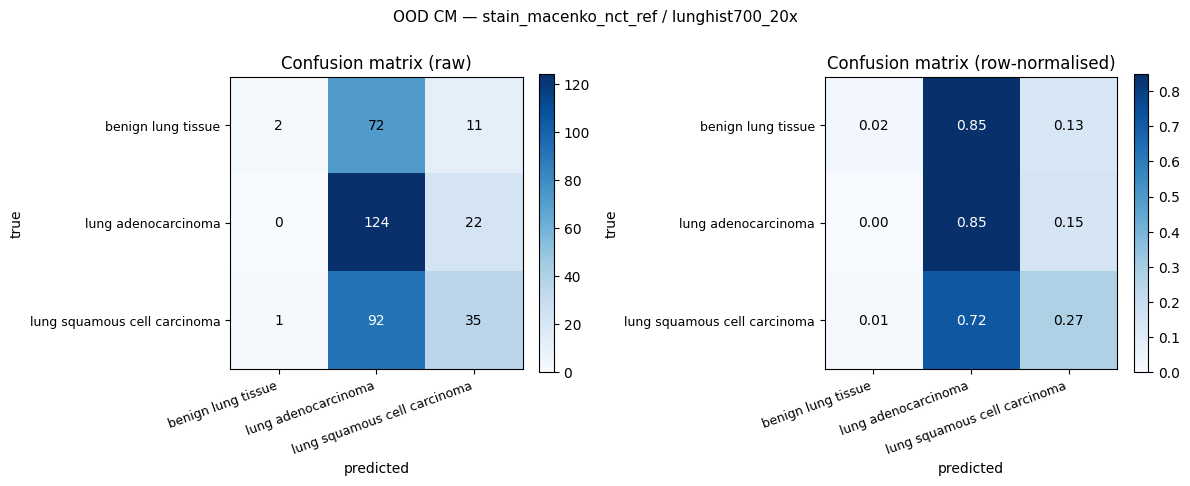

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/stain_macenko_nct_ref_lunghist700_20x_ood_cm.png


In [13]:
# --- Cell: confusion-matrix plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title, fmt, cmap in [
    (axes[0], cm_raw,  "Confusion matrix (raw)",            "d",   "Blues"),
    (axes[1], cm_norm, "Confusion matrix (row-normalised)", ".2f", "Blues"),
]:
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(target_names, rotation=20, ha="right", fontsize=9)
    ax.set_yticklabels(target_names, fontsize=9)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                    color="white" if mat[i, j] > mat.max() * 0.6 else "black", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f"OOD CM — {VARIANT} / {DATASET_TAG}", fontsize=11)
plt.tight_layout()
cm_path = PLOTS_DIR / f"{OUT_TAG}_ood_cm.png"
fig.savefig(cm_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {cm_path}")


## 11 -- LC25000 reference + shared UMAP fit


In [14]:
# --- Cell: LC25000 reference (in-distribution embeddings) ---
import umap
import kagglehub

LC_SPLIT_PATH = results_dir("splits") / f"lc25000_seed{SEED}.json"
if LC_SPLIT_PATH.exists():
    lc_split = load_split(LC_SPLIT_PATH)
    print(f"Loaded LC25000 split from {LC_SPLIT_PATH}")
else:
    print("Downloading LC25000 via kagglehub...")
    lc_dataset_path = kagglehub.dataset_download(
        "andrewmvd/lung-and-colon-cancer-histopathological-images"
    )
    all_paths, all_indices = discover_records(lc_dataset_path)
    lc_split = stratified_split(all_paths, all_indices,
                                val_fraction=0.10, test_fraction=0.10, seed=SEED)
    save_split(lc_split, LC_SPLIT_PATH)

lc_test_paths   = np.asarray(lc_split["test_paths"])
lc_test_indices = np.asarray(lc_split["test_indices"], dtype=np.int32)
print(f"LC25000 test set: {len(lc_test_paths)} images")
for idx in range(len(CLASS_INFO)):
    print(f"  [{idx}] {INDEX_TO_NAME[idx]}: {int((lc_test_indices == idx).sum())}")

lc_target_mask    = np.isin(lc_test_indices, TARGET_LC_IDX)
lc_target_paths   = lc_test_paths[lc_target_mask]
lc_target_indices = lc_test_indices[lc_target_mask]

# Macenko-cache LC25000 test patches so the UMAP scatter + thumbnails reflect the
# model's actual training distribution (LC25000 was Macenko-normalised at train time).
if VARIANT == "stain_macenko_nct_ref":
    lc_test_paths   = _macenko_cache_paths(lc_test_paths, "lc25000_test")
    lc_target_paths = lc_test_paths[lc_target_mask]
    print(f"LC25000 paths rewritten to Macenko cache.")

print(f"\nEncoding {len(lc_test_paths)} LC25000 test images (with VARIANT={VARIANT} preprocessing)...")
_lc_scores, lc_test_features = encode_paths(lc_test_paths)
print(f"LC25000 features: {lc_test_features.shape}")

# Compose vectors for the UMAP: image features + 5 "anchor" vectors (prompts or class directions).
if VARIANT == "plain_classifier":
    anchor_vectors = class_directions
    anchor_kind = "class-direction"
else:
    anchor_vectors = prompt_embeddings_all
    anchor_kind = "prompt"
print(f"Anchor vectors ({anchor_kind}): {anchor_vectors.shape}")

print(f"\nFitting combined UMAP over {len(lc_test_features) + len(ood_features) + len(anchor_vectors)} points...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)
combined = np.vstack([lc_test_features, ood_features, anchor_vectors])
combined_2d = reducer.fit_transform(combined)

n_lc, n_ood = len(lc_test_features), len(ood_features)
lc_2d         = combined_2d[:n_lc]
ood_2d        = combined_2d[n_lc:n_lc + n_ood]
anchor_2d     = combined_2d[n_lc + n_ood:]
lc_target_2d  = lc_2d[lc_target_mask]
anchor_2d_tgt = anchor_2d[TARGET_LC_IDX]
print(f"  lc_2d={lc_2d.shape}  ood_2d={ood_2d.shape}  anchor_2d={anchor_2d.shape}")


100%|██████████| 1.76G/1.76G [00:20<00:00, 92.4MB/s]

Extracting files...


LC25000 test set: 2372 images
  [0] benign lung tissue: 475
  [1] lung adenocarcinoma: 472
  [2] lung squamous cell carcinoma: 473
  [3] benign colon tissue: 477
  [4] colon adenocarcinoma: 475
  [lc25000_test] hydrating from Drive: /content/drive/MyDrive/clip_histopathology/normalized_cache/ood_lc25000_test_macenko_nct_ref_224.tar


/tmp/ipykernel_5225/3075829212.py:62: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(local_root.parent)


    extracted in 2.6s
LC25000 paths rewritten to Macenko cache.

Encoding 2372 LC25000 test images (with VARIANT=stain_macenko_nct_ref preprocessing)...
LC25000 features: (2372, 256)
Anchor vectors (prompt): (5, 256)

Fitting combined UMAP over 2736 points...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  lc_2d=(2372, 2)  ood_2d=(359, 2)  anchor_2d=(5, 2)


## 12 -- 2x3 UMAP grid (scatter + thumbnails)


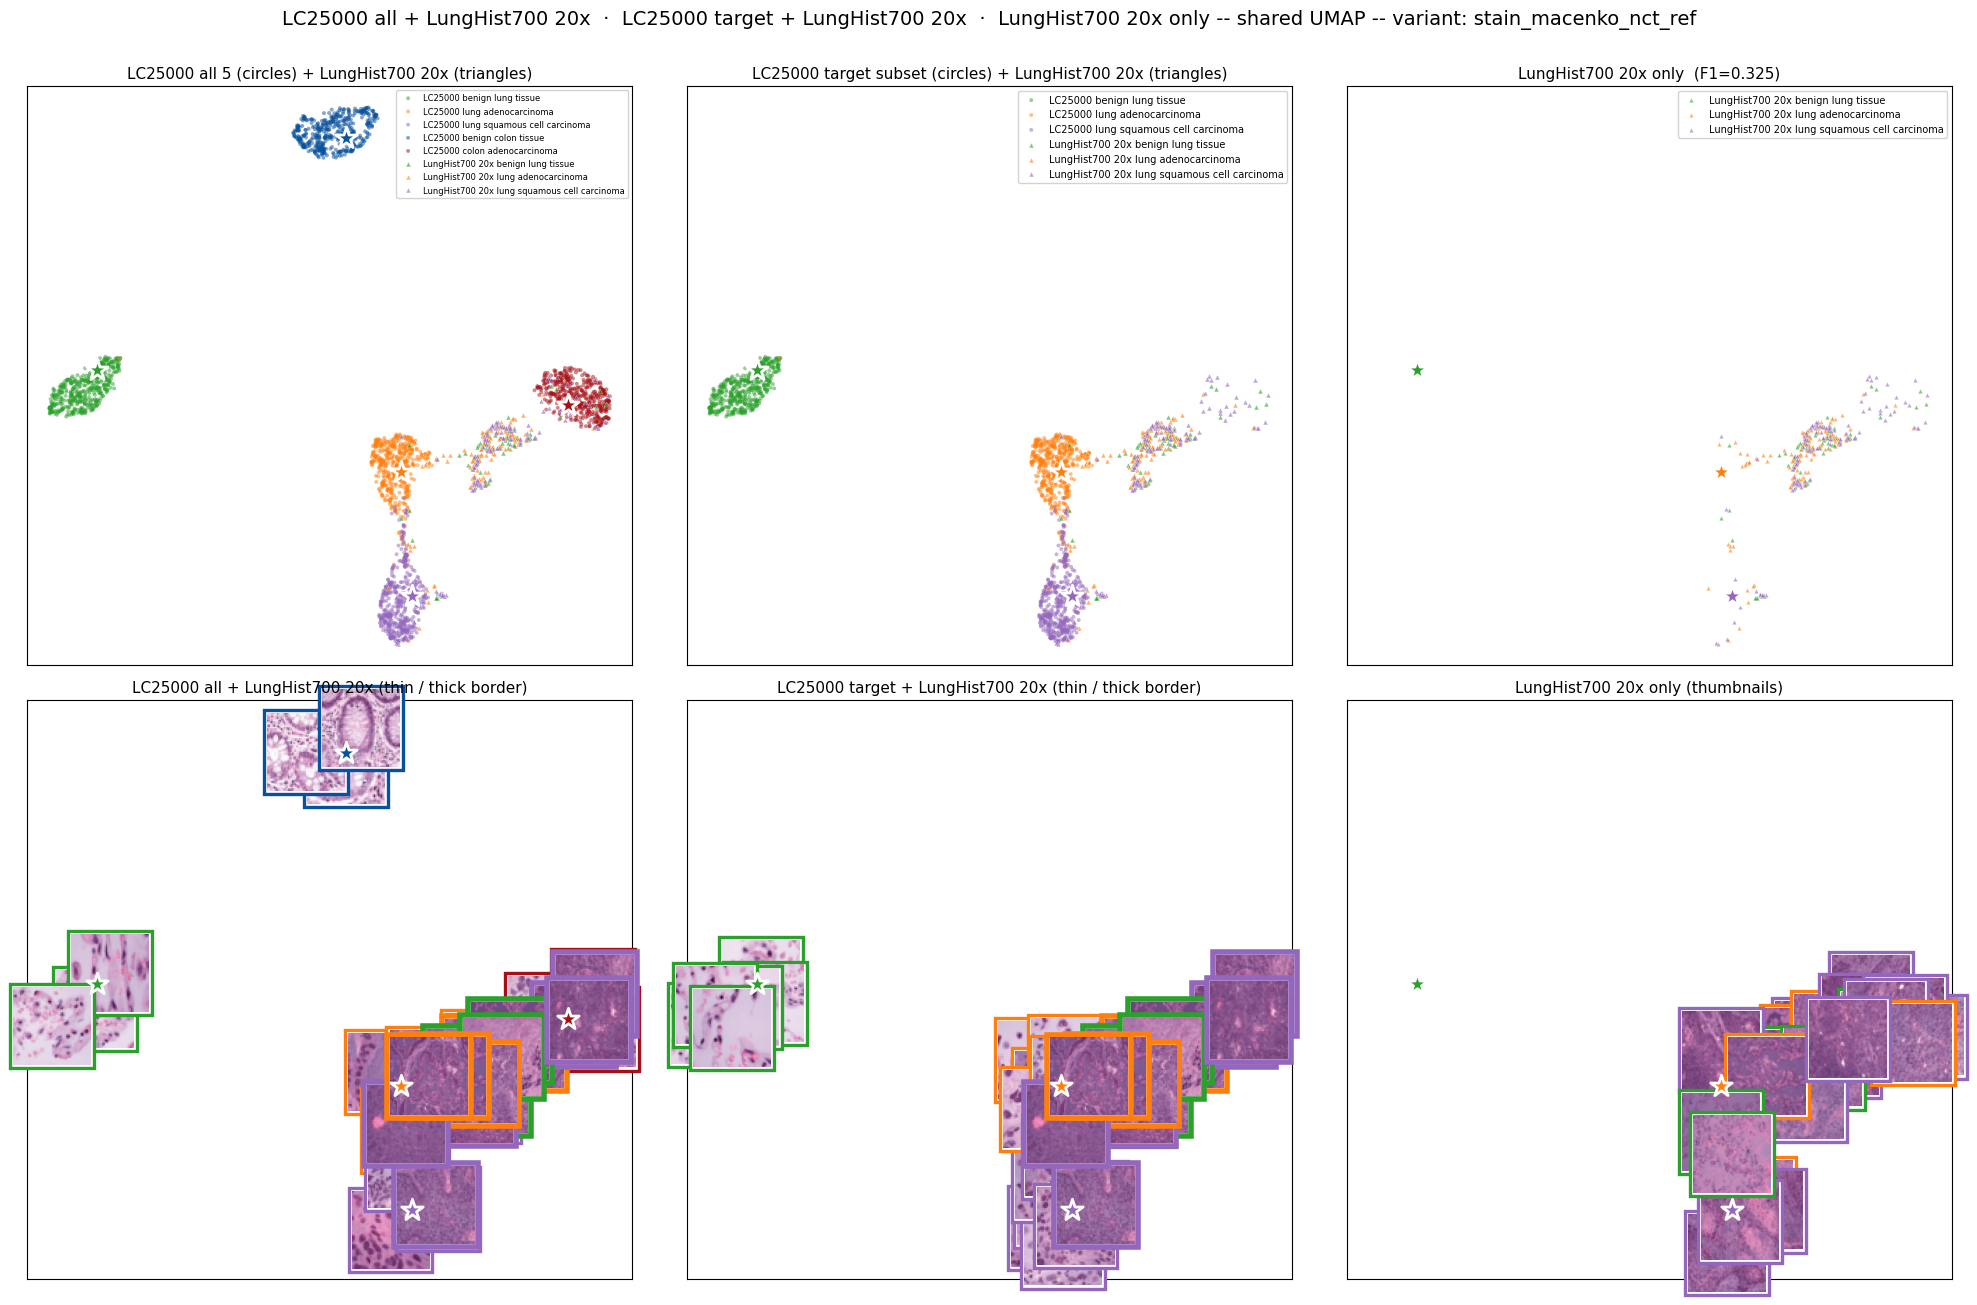

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/stain_macenko_nct_ref_lunghist700_20x_ood_umap_grid.png


In [15]:
# --- Cell: 2x3 UMAP grid (scatter + thumbnails) ---
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import Patch

CLASS_COLOR = {
    0: "#2ca02c",  # benign lung tissue           - green
    1: "#ff7f0e",  # lung adenocarcinoma          - orange
    2: "#9467bd",  # lung squamous cell carcinoma - purple
    3: "#08519c",  # benign colon tissue          - blue
    4: "#a50f15",  # colon adenocarcinoma         - red
}

OOD_LABEL = "LungHist700 20x"


def draw_anchors(ax, anchor_pos, indices, *, with_labels=False, size=260):
    label_prefix = "class" if VARIANT == "plain_classifier" else "prompt"
    for k, idx in enumerate(indices):
        color = CLASS_COLOR[idx]
        ax.scatter(anchor_pos[k, 0], anchor_pos[k, 1], s=size, marker="*",
                   c=color, edgecolors="white", linewidths=2.0, zorder=6)
        if with_labels:
            ax.annotate(f"{label_prefix}:\n{INDEX_TO_NAME[idx]}",
                        (anchor_pos[k, 0], anchor_pos[k, 1]),
                        xytext=(12, 10), textcoords="offset points",
                        fontsize=8, fontweight="bold", zorder=7,
                        bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                                  edgecolor=color, alpha=0.9, linewidth=1.5))


def _scatter_ood(ax, alpha=0.55, size=10):
    """Scatter OOD points colour-coded by their mapped LC25000 class index."""
    for idx in sorted(set(ood_lc_indices.tolist())):
        mask = (ood_lc_indices == idx)
        ax.scatter(ood_2d[mask, 0], ood_2d[mask, 1], s=size, alpha=alpha,
                   c=CLASS_COLOR[idx], marker="^",
                   label=f"{OOD_LABEL} {INDEX_TO_NAME[idx]}",
                   edgecolors="white", linewidths=0.3)


def _read_thumb(path, size=(56, 56)):
    try:
        return np.asarray(Image.open(path).convert("RGB").resize(size, Image.BILINEAR))
    except Exception:
        return np.full((size[1], size[0], 3), 200, dtype=np.uint8)


def _layout_thumbnails(ax, coords, paths, class_colors, *, max_thumbs=35,
                       thumb_size=(56, 56), min_dist_frac=0.06, seed=42, border_width=2.4):
    coords = np.asarray(coords)
    rng = np.random.default_rng(seed)
    x_range = float(coords[:, 0].max() - coords[:, 0].min())
    y_range = float(coords[:, 1].max() - coords[:, 1].min())
    min_dist = min_dist_frac * min(x_range, y_range)
    idx = np.arange(len(coords)); rng.shuffle(idx)
    placed = []
    for i in idx:
        x, y = float(coords[i, 0]), float(coords[i, 1])
        if any((x - px) ** 2 + (y - py) ** 2 < min_dist ** 2 for (px, py) in placed):
            continue
        thumb = _read_thumb(paths[i], size=thumb_size)
        ab = AnnotationBbox(OffsetImage(thumb, zoom=1.0), (x, y),
                            frameon=True, pad=0.22,
                            bboxprops=dict(linewidth=border_width, edgecolor=class_colors[i]))
        ax.add_artist(ab)
        placed.append((x, y))
        if len(placed) >= max_thumbs:
            break
    return len(placed)


fig, axes = plt.subplots(2, 3, figsize=(20, 13))

x_min = min(lc_2d[:, 0].min(), ood_2d[:, 0].min(), anchor_2d[:, 0].min())
x_max = max(lc_2d[:, 0].max(), ood_2d[:, 0].max(), anchor_2d[:, 0].max())
y_min = min(lc_2d[:, 1].min(), ood_2d[:, 1].min(), anchor_2d[:, 1].min())
y_max = max(lc_2d[:, 1].max(), ood_2d[:, 1].max(), anchor_2d[:, 1].max())
pad_x = 0.04 * (x_max - x_min); pad_y = 0.04 * (y_max - y_min)
XLIM = (x_min - pad_x, x_max + pad_x); YLIM = (y_min - pad_y, y_max + pad_y)


def _box(ax, title):
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=11)


# ROW 1: SCATTER
ax = axes[0, 0]
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=8, alpha=0.5,
               c=CLASS_COLOR[idx], marker="o", label=f"LC25000 {INDEX_TO_NAME[idx]}", edgecolors="none")
_scatter_ood(ax, alpha=0.6, size=12)
draw_anchors(ax, anchor_2d, list(range(len(CLASS_INFO))))
ax.legend(loc="best", fontsize=6, framealpha=0.85)
_box(ax, f"LC25000 all 5 (circles) + {OOD_LABEL} (triangles)")

ax = axes[0, 1]
for idx in TARGET_LC_IDX:
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=8, alpha=0.5,
               c=CLASS_COLOR[idx], marker="o", label=f"LC25000 {INDEX_TO_NAME[idx]}", edgecolors="none")
_scatter_ood(ax, alpha=0.6, size=12)
draw_anchors(ax, anchor_2d_tgt, TARGET_LC_IDX)
ax.legend(loc="best", fontsize=7, framealpha=0.85)
_box(ax, f"LC25000 target subset (circles) + {OOD_LABEL} (triangles)")

ax = axes[0, 2]
_scatter_ood(ax, alpha=0.6, size=10)
draw_anchors(ax, anchor_2d_tgt, TARGET_LC_IDX)
ax.legend(loc="best", fontsize=7, framealpha=0.85)
_box(ax, f"{OOD_LABEL} only  (F1={macro_f1:.3f})")


# ROW 2: THUMBNAILS
ax = axes[1, 0]
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=5, alpha=0.12, c=CLASS_COLOR[idx], marker="o")
_scatter_ood(ax, alpha=0.18, size=5)
_layout_thumbnails(ax, lc_2d, list(lc_test_paths),
    [CLASS_COLOR[int(lc_test_indices[i])] for i in range(len(lc_test_paths))],
    max_thumbs=25, min_dist_frac=0.07, seed=SEED, border_width=2.4)
_layout_thumbnails(ax, ood_2d, list(ood_paths),
    [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))],
    max_thumbs=15, min_dist_frac=0.07, seed=SEED + 1, border_width=4.0)
draw_anchors(ax, anchor_2d, list(range(len(CLASS_INFO))))
_box(ax, f"LC25000 all + {OOD_LABEL} (thin / thick border)")

ax = axes[1, 1]
for idx in TARGET_LC_IDX:
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=5, alpha=0.12, c=CLASS_COLOR[idx], marker="o")
_scatter_ood(ax, alpha=0.18, size=5)
_layout_thumbnails(ax, lc_target_2d, list(lc_target_paths),
    [CLASS_COLOR[int(lc_target_indices[i])] for i in range(len(lc_target_paths))],
    max_thumbs=20, min_dist_frac=0.07, seed=SEED, border_width=2.4)
_layout_thumbnails(ax, ood_2d, list(ood_paths),
    [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))],
    max_thumbs=15, min_dist_frac=0.07, seed=SEED + 1, border_width=4.0)
draw_anchors(ax, anchor_2d_tgt, TARGET_LC_IDX)
_box(ax, f"LC25000 target + {OOD_LABEL} (thin / thick border)")

ax = axes[1, 2]
_scatter_ood(ax, alpha=0.20, size=5)
_layout_thumbnails(ax, ood_2d, list(ood_paths),
    [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))],
    max_thumbs=30, min_dist_frac=0.06, seed=SEED, border_width=2.4)
draw_anchors(ax, anchor_2d_tgt, TARGET_LC_IDX)
_box(ax, f"{OOD_LABEL} only (thumbnails)")


fig.suptitle(f"LC25000 all + {OOD_LABEL}  ·  LC25000 target + {OOD_LABEL}  ·  {OOD_LABEL} only "
             f"-- shared UMAP -- variant: {VARIANT}", fontsize=14, y=1.005)
plt.tight_layout()
p_grid = PLOTS_DIR / f"{OUT_TAG}_ood_umap_grid.png"
fig.savefig(p_grid, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p_grid}")


## Summary

Run-time output (filenames include the active `VARIANT` and dataset tag):
- `results/metrics/exp_07_ood_eval/{VARIANT}_lunghist700_20x_ood_classification.json`
- `results/confusion_matrices/exp_07_ood_eval/{VARIANT}_lunghist700_20x_ood_cm_{raw,norm}.npy`
- `results/plots/exp_07_ood_eval/{VARIANT}_lunghist700_20x_ood_cm.png`
- `results/plots/exp_07_ood_eval/{VARIANT}_lunghist700_20x_ood_umap_grid.png`

**To run a different variant**, change `VARIANT` in Cell 2 and re-execute from the model-construction cell onwards (the bootstrap, imports, config, and dataset cells are variant-agnostic). Each variant writes its own files so re-runs are non-destructive.

**Prereq:** the training notebook for the selected VARIANT must have been run first to produce `<RUN_DIR>/weights.weights.h5` on Drive. See the run paths printed by Cell 2.
